In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# STREAMLIT

FINANCIAL PROFILE

1. Customer Financial Strength and Subscription Conversion

# FINANCIAL PROFILE

1. Customer Account Balance and Conversion Rate

Conversion rate by balance segment:
balance_segment
Lower Balance        0.072369
Lower-Mid Balance    0.108936
Upper-Mid Balance    0.125155
Higher Balance       0.161547
Name: converted, dtype: float64

Average balance by segment:
balance_segment
Lower Balance         -95.019086
Lower-Mid Balance     241.565140
Upper-Mid Balance     839.354414
Higher Balance       4465.589094
Name: balance, dtype: float64


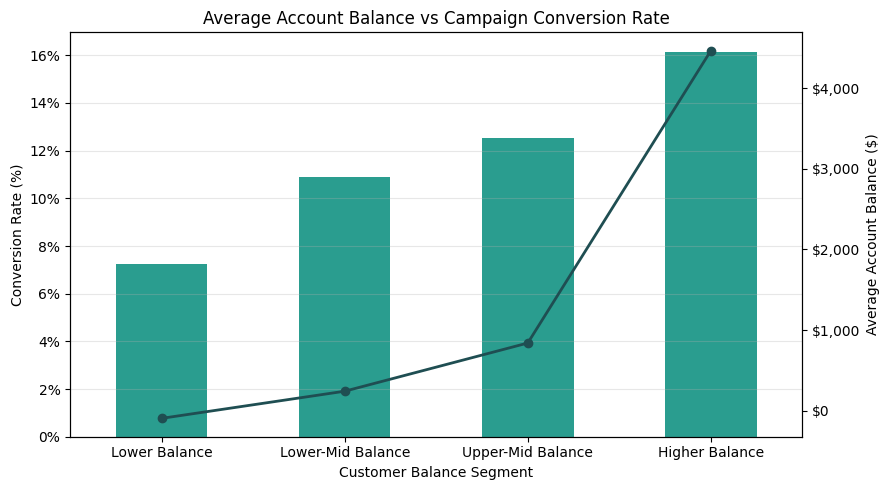

In [ ]:
# Load dataset
df = pd.read_csv("../../data/raw/bank-full.csv", sep=";")

# Convert target to numeric
df["converted"] = df["y"].map({"yes": 1, "no": 0})

# Create balance quartiles
df["balance_segment"] = pd.qcut(
    df["balance"],
    q=4,
    labels=["Lower Balance", "Lower-Mid Balance", "Upper-Mid Balance", "Higher Balance"],
    duplicates="drop"
)

# Calculate conversion rate
conversion_by_balance = df.groupby("balance_segment", observed=True)["converted"].mean()

# Calculate average balance
avg_balance = df.groupby("balance_segment", observed=True)["balance"].mean()

print("Conversion rate by balance segment:")
print(conversion_by_balance)

print("\nAverage balance by segment:")
print(avg_balance)

# Create figure
fig, ax1 = plt.subplots(figsize=(9,5))

# Bar chart (conversion rate)
conversion_by_balance.plot(
    kind="bar",
    ax=ax1,
    color="#2a9d8f"
)

ax1.set_ylabel("Conversion Rate (%)")
ax1.set_xlabel("Customer Balance Segment")
ax1.set_title("Average Account Balance vs Campaign Conversion Rate")
ax1.grid(axis="y", alpha=0.3)

# Format conversion rate axis as percentages
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Force horizontal labels
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Line chart (average balance)
ax2 = ax1.twinx()
ax2.plot(
    avg_balance.values,
    marker="o",
    linewidth=2,
    color="#1F4E52"
)

ax2.set_ylabel("Average Account Balance ($)")

# Format balance axis as dollars
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

2. Customer Debt Profile vs Likelihood of Subscription

Conversion rate by existing financial products:
existing_products
Housing + Personal Loan    0.060935
Credit Default             0.063804
Personal Loan              0.077889
Housing Loan               0.080543
No Loan Products           0.183616
Name: converted, dtype: float64


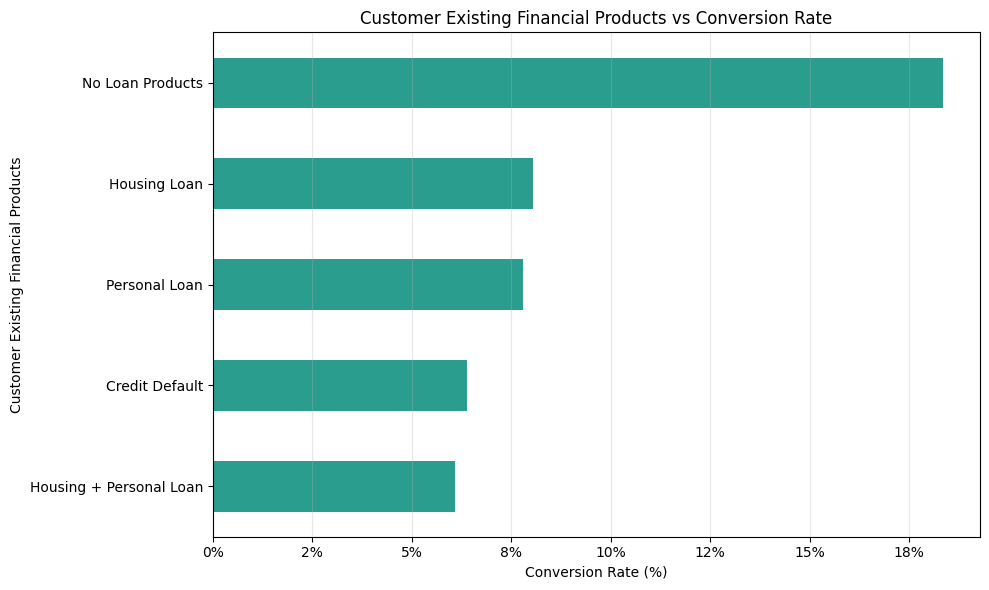

In [ ]:
# Load dataset
df = pd.read_csv("../../data/raw/bank-full.csv", sep=";")

# Convert target to numeric
df["converted"] = df["y"].map({"yes": 1, "no": 0})

# Create customer existing financial products category
def existing_products(row):
    if row["default"] == "yes":
        return "Credit Default"

    if row["housing"] == "yes" and row["loan"] == "yes":
        return "Housing + Personal Loan"

    if row["housing"] == "yes":
        return "Housing Loan"

    if row["loan"] == "yes":
        return "Personal Loan"

    return "No Loan Products"


df["existing_products"] = df.apply(existing_products, axis=1)

# Calculate conversion rate by product holding
conversion_by_products = df.groupby("existing_products")["converted"].mean().sort_values()

print("Conversion rate by existing financial products:")
print(conversion_by_products)

# Plot
fig, ax = plt.subplots(figsize=(10,6))

conversion_by_products.plot(
    kind="barh",
    ax=ax,
    color="#2a9d8f"
)

ax.set_title("Customer Existing Financial Products vs Conversion Rate")
ax.set_xlabel("Conversion Rate (%)")
ax.set_ylabel("Customer Existing Financial Products")
ax.grid(axis="x", alpha=0.3)

# Format x-axis as percentages
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.show()


In [ ]:
3. Balance Segment × Existing Financial Products vs Conversion Rate

Conversion rate by balance segment and existing financial products:
existing_products  Credit Default  Housing + Personal Loan  Housing Loan  \
balance_segment                                                            
Lower Balance            0.059767                 0.062952      0.063052   
Lower-Mid Balance        0.060241                 0.060306      0.070195   
Upper-Mid Balance        0.153846                 0.056365      0.085395   
Higher Balance           0.000000                 0.064607      0.103682   

existing_products  No Loan Products  Personal Loan  
balance_segment                                     
Lower Balance              0.093932       0.058957  
Lower-Mid Balance          0.183177       0.074510  
Upper-Mid Balance          0.199471       0.088710  
Higher Balance             0.232796       0.106335  


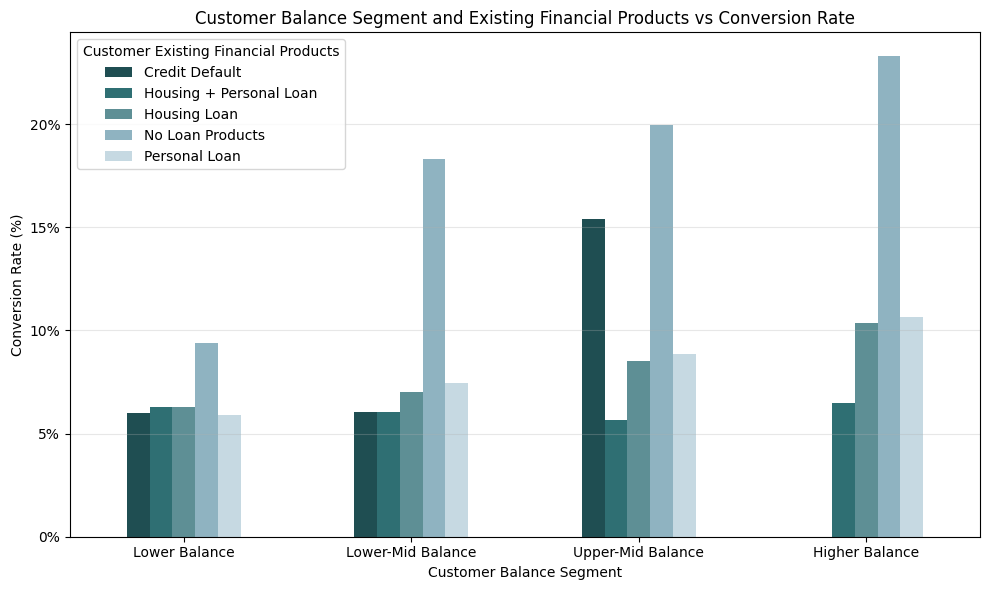

In [ ]:
# Load dataset
df = pd.read_csv("../../data/raw/bank-full.csv", sep=";")

# Convert target to numeric
df["converted"] = df["y"].map({"yes": 1, "no": 0})

# Create balance segments
df["balance_segment"] = pd.qcut(
    df["balance"],
    q=4,
    labels=["Lower Balance", "Lower-Mid Balance", "Upper-Mid Balance", "Higher Balance"],
    duplicates="drop"
)

# Create customer existing financial products category
def existing_products(row):

    if row["default"] == "yes":
        return "Credit Default"

    if row["housing"] == "yes" and row["loan"] == "yes":
        return "Housing + Personal Loan"

    if row["housing"] == "yes":
        return "Housing Loan"

    if row["loan"] == "yes":
        return "Personal Loan"

    return "No Loan Products"


df["existing_products"] = df.apply(existing_products, axis=1)

# Calculate conversion rate by balance and product holding
conversion_matrix = (
    df.groupby(["balance_segment", "existing_products"], observed=True)["converted"]
    .mean()
    .unstack()
)

print("Conversion rate by balance segment and existing financial products:")
print(conversion_matrix)

# Plot
fig, ax = plt.subplots(figsize=(10,6))

conversion_matrix.plot(
    kind="bar",
    ax=ax,
    color=[
        "#1F4E52",  # Credit Default
        "#2F6F73",  # Housing + Personal Loan
        "#5E8F95",  # Housing Loan
        "#8FB3C1",  # Personal Loan
        "#C6D9E2"   # No Loan Products
    ]
)

ax.set_title("Customer Balance Segment and Existing Financial Products vs Conversion Rate")
ax.set_xlabel("Customer Balance Segment")
ax.set_ylabel("Conversion Rate (%)")
ax.grid(axis="y", alpha=0.3)

# Format y-axis as percentages
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Keep labels horizontal
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add legend title
ax.legend(title="Customer Existing Financial Products")

plt.tight_layout()
plt.show()
